<a href="https://colab.research.google.com/github/JozefSL/EIA/blob/main/ExtractWTIdataSTEOhistory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import os # Import the os module for file operations

url = 'https://www.eia.gov/outlooks/steo/outlook.php'

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    soup = BeautifulSoup(response.text, 'html.parser')

    print("Successfully fetched the webpage. Now looking for download links...")

    all_links = []
    for a_tag in soup.find_all('a', href=True):
        href = a_tag['href']
        # Resolve relative URLs to absolute URLs
        if not href.startswith('http'):
            href = requests.compat.urljoin(url, href)
        all_links.append(href)

    # Filter for historical forecast data files (ending in .xlsx or .xls and in archives)
    # Sort in reverse to process newest first, assuming this is desired for initial inspection
    historical_data_links = sorted([link for link in all_links if ('archives' in link and (link.endswith('.xlsx') or link.endswith('.xls')))], reverse=True)

    if historical_data_links:
        print(f"Found {len(historical_data_links)} potential historical forecast data links in archives.")
        print("Downloading and processing files...")

        all_extracted_rows = []

        for link_idx, link in enumerate(historical_data_links):
            file_name = link.split('/')[-1]
            print(f"({link_idx + 1}/{len(historical_data_links)}) Attempting to download {file_name} from: {link}")

            try:
                file_response = requests.get(link, stream=True)
                file_response.raise_for_status()

                with open(file_name, 'wb') as f:
                    for chunk in file_response.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"Successfully downloaded {file_name}")

                # Read the '2tab' sheet into a pandas DataFrame without headers
                if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
                    try:
                        df_raw = pd.read_excel(file_name, sheet_name='2tab', header=None)

                        # Extract relevant rows (0-indexed)
                        year_row = df_raw.iloc[2] # Row 3 in Excel
                        month_row = df_raw.iloc[3] # Row 4 in Excel
                        data_row = df_raw.iloc[5] # Row 6 in Excel

                        current_year = None
                        # Iterate through columns starting from the third column (index 2)
                        for col_idx in range(2, len(data_row)):
                            # Update current_year from row 3, handling merged cells (NaNs)
                            if pd.notna(year_row[col_idx]):
                                try:
                                    current_year = int(year_row[col_idx])
                                except ValueError:
                                    current_year = None # Reset if not a valid year number

                            month = month_row[col_idx]
                            value = data_row[col_idx]

                            # Only append if we have valid year, month, and value
                            if current_year is not None and pd.notna(month) and pd.notna(value):
                                all_extracted_rows.append({
                                    'Year': current_year,
                                    'Month': month,
                                    'Value': value,
                                    'Source_File': file_name
                                })
                        print(f"Successfully extracted data from '2tab' row 6 of {file_name}.")

                    except ValueError as ve:
                        print(f"Sheet '2tab' not found or other parsing error in {file_name}: {ve}")
                    except Exception as e:
                        print(f"Error reading Excel file {file_name} (sheet '2tab'): {e}")

                # Clean up the downloaded file after processing
                os.remove(file_name)
                print(f"Removed temporary file: {file_name}")

            except requests.exceptions.RequestException as e:
                print(f"Error downloading {file_name} from {link}: {e}")
            except Exception as e:
                print(f"An unexpected error occurred while processing {file_name}: {e}")

        if all_extracted_rows:
            print("\nConcatenating all extracted data into a final DataFrame...")
            final_df = pd.DataFrame(all_extracted_rows)
            print("Concatenation complete. Head of the final DataFrame:")
            print(final_df.head())
            print(f"Total rows in the combined DataFrame: {len(final_df)}")
        else:
            print("No data from '2tab' sheets could be read and concatenated.")

    else:
        print("No direct historical forecast data files (.xls, .xlsx) found in archives.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL or general request error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully fetched the webpage. Now looking for download links...
Found 260 potential historical forecast data links in archives.
(1/260) Attempting to download sep25_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep25_base.xlsx
Successfully downloaded sep25_base.xlsx
Successfully extracted data from '2tab' row 6 of sep25_base.xlsx.
Removed temporary file: sep25_base.xlsx
(2/260) Attempting to download sep24_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep24_base.xlsx
Successfully downloaded sep24_base.xlsx
Successfully extracted data from '2tab' row 6 of sep24_base.xlsx.
Removed temporary file: sep24_base.xlsx
(3/260) Attempting to download sep23_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep23_base.xlsx
Successfully downloaded sep23_base.xlsx
Successfully extracted data from '2tab' row 6 of sep23_base.xlsx.
Removed temporary file: sep23_base.xlsx
(4/260) Attempting to download sep22_base.xlsx from: https://www.eia.gov/outlooks/steo/archive

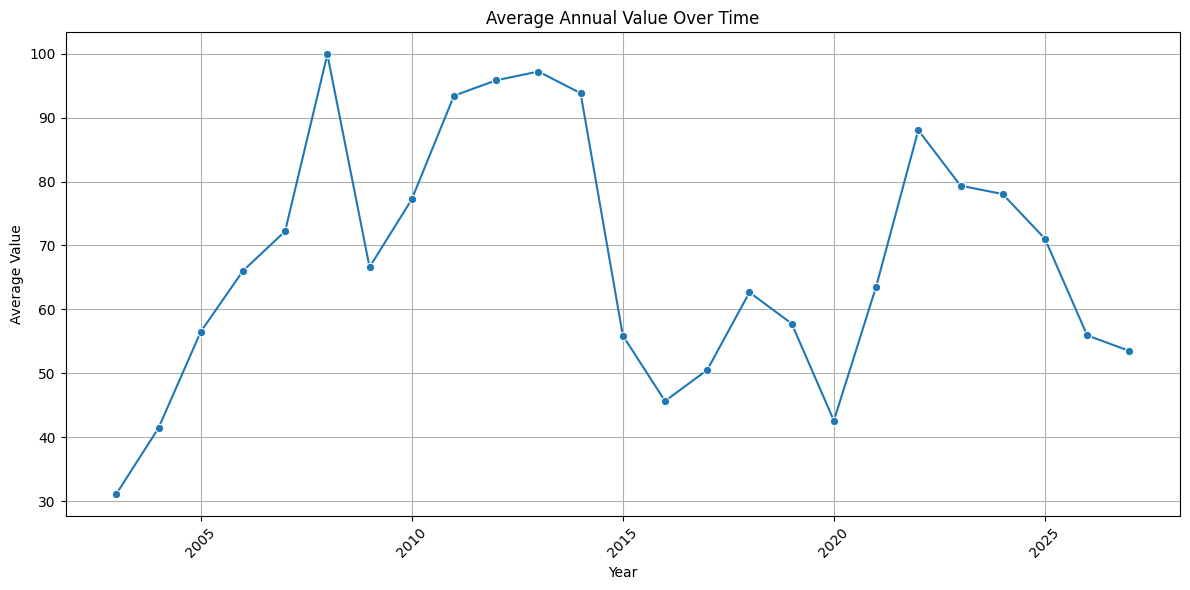

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average annual 'Value'
annual_avg_value = final_df.groupby('Year')['Value'].mean().reset_index()

# Plotting the average annual 'Value'
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Value', data=annual_avg_value, marker='o')
plt.title('Average Annual Value Over Time')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
final_df.head()

,Year,Month,Value,Source_File
0,2021,Jan,52.00,sep25_base.xlsx
1,2021,Feb,59.04,sep25_base.xlsx
2,2021,Mar,62.33,sep25_base.xlsx
3,2021,Apr,61.72,sep25_base.xlsx
4,2021,May,65.17,sep25_base.xlsx


In [8]:
import plotly.express as px
import pandas as pd

# Filter the DataFrame for 'aug25_base.xlsx'
df_aug25 = final_df[final_df['Source_File'] == 'aug25_base.xlsx'].copy()

# Ensure 'Year' is integer and 'Month' is string for plotting
df_aug25['Year'] = df_aug25['Year'].astype(int)

# Create a date-like column for better time series plotting
# Assuming 'Month' is a month name, we can map it to a number or concatenate with year
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_aug25['Month_Num'] = df_aug25['Month'].map(month_to_num)

# Create a 'Date' column for plotting
df_aug25['Date'] = pd.to_datetime(df_aug25['Year'].astype(str) + '-' + df_aug25['Month_Num'].astype(str) + '-01')

# Sort by Date to ensure correct plotting order
df_aug25 = df_aug25.sort_values(by='Date')

# Plotting the 'Value' for 'aug25_base.xlsx' over time using Plotly Express for interactivity
fig = px.line(df_aug25, x='Date', y='Value', title='Value Over Time for Source File: aug25_base.xlsx',
              hover_data={'Date': '|%Y-%m-%d', 'Value': True})

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Value',
    xaxis_tickformat='%Y-%m'
)

fig.show()


Forecasted Wells (head):


,Date,ln_wells,Wells
0,2025-08-01,6.149612,468.535699
1,2025-09-01,6.136797,462.569689
2,2025-10-01,6.119203,454.502408
3,2025-11-01,6.104617,447.920841
4,2025-12-01,6.089563,441.228751


Forecasted Wells (tail):


,Date,ln_wells,Wells
12,2026-08-01,6.060148,428.438984
13,2026-09-01,6.061025,428.814659
14,2026-10-01,6.055809,426.583703
15,2026-11-01,6.065852,430.889666
16,2026-12-01,6.066670,431.242312


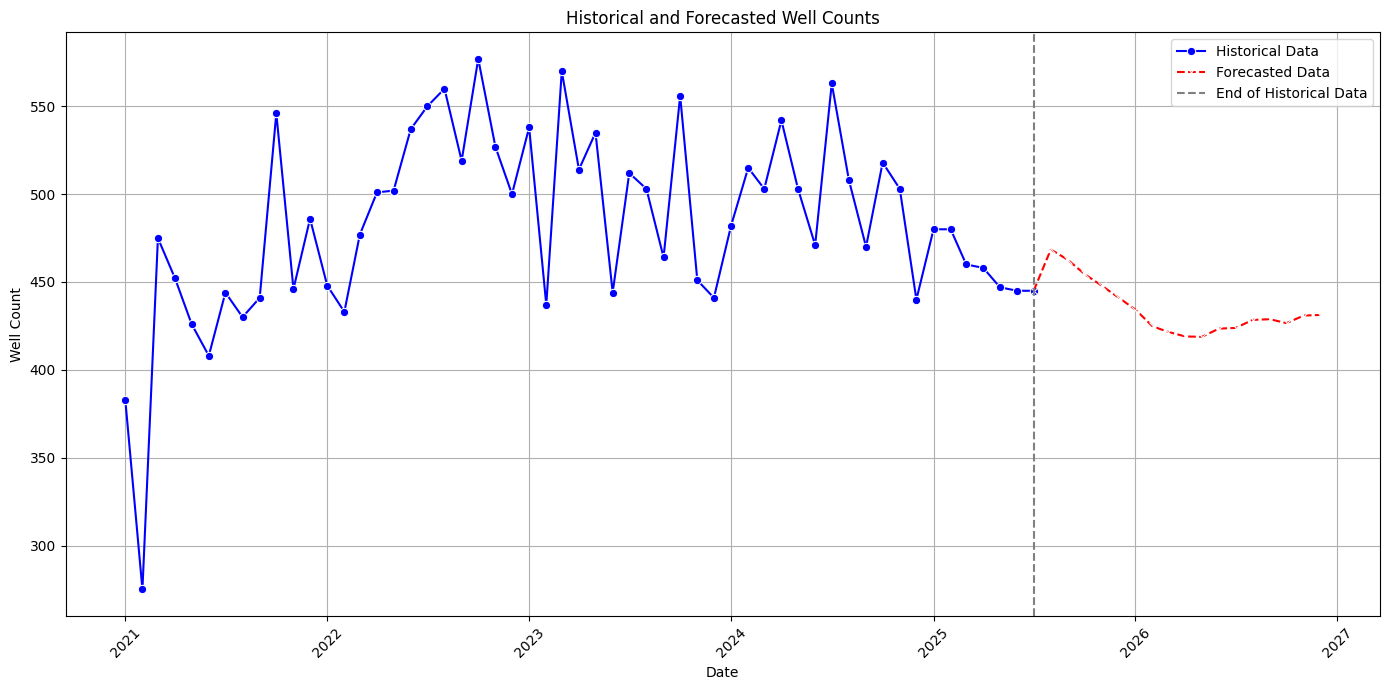

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve coefficients from previous step (assuming they are in the global scope)
# a0, a1, rho
# Ensure lag_price is also available, from previous execution it was 1
lag_price = 1

# 1. Get the last historical data point for wells
last_historical_date = combined_df['Date'].max()
last_historical_ln_wells = combined_df['ln_wells'].iloc[-1]
last_historical_wells = combined_df['Wells'].iloc[-1]

# 2. Define the forecast period and get corresponding future prices
# The combined_df ends at last_historical_date. The forecast starts the month after.
forecast_start_date = last_historical_date + pd.DateOffset(months=1)

# Filter df_aug25 for prices relevant to the forecast period.
# We need prices for t-lag, so we need prices up to the end of the forecast period.
# The end of df_aug25 is '2026-08-01'.

future_prices_df = df_aug25[df_aug25['Date'] >= forecast_start_date].copy()

# Calculate ln_price for future prices
future_prices_df['ln_price'] = np.log(future_prices_df['Value'])

# Prepare for iteration
forecasted_ln_wells = []
forecasted_dates = []

# Initialize ln(wells(t-1)) for the first forecast step
current_ln_wells_t_minus_1 = last_historical_ln_wells

# Iterate through the future prices to forecast wells
for i in range(len(future_prices_df)):
    current_date = future_prices_df['Date'].iloc[i]

    # The price for ln(price(t-lag)) needs to be found for the current month being forecast
    # If forecasting for month M, then current_ln_wells_t_minus_1 is from M-1.
    # The price for ln(price(t-lag)) is (M - lag_price) month's price.
    # So, for forecasting wells for current_date (t+1), we need price from current_date - lag_price
    price_date_for_lag = current_date - pd.DateOffset(months=lag_price)

    # Get the ln_price(t-lag) from future_prices_df or combined_df if it's still in the historical range
    if price_date_for_lag >= combined_df['Date'].min(): # check if the price date is within known data
        if price_date_for_lag <= last_historical_date:
            ln_price_t_minus_lag = combined_df[combined_df['Date'] == price_date_for_lag]['ln_price'].iloc[0]
        else:
            ln_price_t_minus_lag = future_prices_df[future_prices_df['Date'] == price_date_for_lag]['ln_price'].iloc[0]
    else:
        # This case should ideally not happen if the forecast period is well-defined
        # relative to price data. For now, we'll use NaN and drop it later, or raise error
        ln_price_t_minus_lag = np.nan

    # If ln_price_t_minus_lag is NaN, we cannot forecast this step.
    if pd.isna(ln_price_t_minus_lag):
        print(f"Warning: Could not find price for {price_date_for_lag}. Stopping forecast.")
        break

    # Apply the regression equation
    # ln(wells(t+1)) = a0 + (a1 * ln(price(t-lag))) + (rho * ln(wells(t-1)))
    predicted_ln_wells_t_plus_1 = a0 + (a1 * ln_price_t_minus_lag) + (rho * current_ln_wells_t_minus_1)

    forecasted_ln_wells.append(predicted_ln_wells_t_plus_1)
    forecasted_dates.append(current_date)

    # Update ln(wells(t-1)) for the next iteration
    current_ln_wells_t_minus_1 = predicted_ln_wells_t_plus_1

# Create a DataFrame for forecasted results
forecast_df = pd.DataFrame({
    'Date': forecasted_dates,
    'ln_wells': forecasted_ln_wells
})
forecast_df['Wells'] = np.exp(forecast_df['ln_wells'])

print("Forecasted Wells (head):")
display(forecast_df.head())

print("Forecasted Wells (tail):")
display(forecast_df.tail())

# Prepare forecast data for plotting to ensure continuity
# Get the last historical point
last_historical_point = combined_df[['Date', 'Wells']].iloc[[-1]]

# Concatenate the last historical point with the forecast_df
# This will make the forecast line start from the last historical point
forecast_plot_df = pd.concat([last_historical_point, forecast_df[['Date', 'Wells']]], ignore_index=True)

# Plotting
plt.figure(figsize=(14, 7))

# Plot historical data
sns.lineplot(x='Date', y='Wells', data=combined_df, marker='o', label='Historical Data', color='blue')

# Plot forecasted data using forecast_plot_df for continuity
sns.lineplot(x='Date', y='Wells', data=forecast_plot_df, marker='x', label='Forecasted Data', color='red', linestyle='--')

plt.axvline(x=last_historical_date, color='grey', linestyle='--', label='End of Historical Data')
plt.title('Historical and Forecasted Well Counts')
plt.xlabel('Date')
plt.ylabel('Well Count')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import statsmodels.api as sm
import numpy as np

# Ensure 'combined_df' is sorted by date
combined_df = combined_df.sort_values(by='Date').reset_index(drop=True)

# Calculate natural logarithms
combined_df['ln_wells'] = np.log(combined_df['Wells'])
combined_df['ln_price'] = np.log(combined_df['Price'])

# Define the lag for price and wells as per the equation
lag_price = 1 # user specified
lag_wells = 1 # fixed at 1 for ln(wells(t-1))

# Create lagged variables
# ln(wells(t+1)) is the dependent variable, so it's ln_wells shifted up by 1 (or current index + 1)
combined_df['ln_wells_t_plus_1'] = combined_df['ln_wells'].shift(-1)
# ln(price(t-lag)) is ln_price shifted down by 'lag_price'
combined_df['ln_price_t_minus_lag'] = combined_df['ln_price'].shift(lag_price)
# ln(wells(t-1)) is ln_wells shifted down by 'lag_wells'
combined_df['ln_wells_t_minus_1'] = combined_df['ln_wells'].shift(lag_wells)

# Drop rows with NaN values resulting from shifting
regression_df = combined_df.dropna().copy()

# Define dependent and independent variables for the regression
Y = regression_df['ln_wells_t_plus_1']
X = regression_df[['ln_price_t_minus_lag', 'ln_wells_t_minus_1']]

# Add a constant to the independent variables for the intercept (a0)
X = sm.add_constant(X)

# Run the OLS regression
model = sm.OLS(Y, X)
results = model.fit()

# Print the regression summary
print(results.summary())

# Extract coefficients
a0 = results.params['const']
a1 = results.params['ln_price_t_minus_lag']
rho = results.params['ln_wells_t_minus_1']

print(f"\nDerived Coefficients:")
print(f"a0 (intercept): {a0:.4f}")
print(f"a1 (ln(price(t-lag)) coefficient): {a1:.4f}")
print(f"rho (ln(wells(t-1)) coefficient): {rho:.4f}")


                            OLS Regression Results                            
Dep. Variable:      ln_wells_t_plus_1   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     9.215
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           0.000392
Time:                        14:24:47   Log-Likelihood:                 61.909
No. Observations:                  53   AIC:                            -117.8
Df Residuals:                      50   BIC:                            -111.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.5694 

In [9]:
import pandas as pd
import numpy as np

# Provided well count series
wells_series = [383, 275, 475, 452, 426, 408, 444, 430, 441, 546, 446, 486, 448, 433, 477, 501, 502, 537, 550, 560, 519, 577, 527, 500, 538, 437, 570, 514, 535, 444, 512, 503, 464, 556, 451, 441, 482, 515, 503, 542, 503, 471, 563, 508, 470, 518, 503, 440, 480, 480, 460, 458, 447, 445, 445]

# Create a date range for the wells data (Jan 2021 to Jul 2025)
start_date = '2021-01-01'
end_date = '2025-07-01'
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Create a DataFrame for wells data
wells_df = pd.DataFrame({'Date': date_range, 'Wells': wells_series})

# Merge df_aug25 (price data) with wells_df
# Ensure df_aug25 has a 'Date' column for merging
if 'Date' not in df_aug25.columns:
    df_aug25['Date'] = pd.to_datetime(df_aug25['Year'].astype(str) + '-' + df_aug25['Month_Num'].astype(str) + '-01')

# Filter df_aug25 to match the wells data date range
df_aug25_filtered = df_aug25[(df_aug25['Date'] >= start_date) & (df_aug25['Date'] <= end_date)]

# Merge the two DataFrames
# We'll use 'Value' from df_aug25 as 'Price'
combined_df = pd.merge(wells_df, df_aug25_filtered[['Date', 'Value']], on='Date', how='inner')
combined_df.rename(columns={'Value': 'Price'}, inplace=True)

print("Combined DataFrame head:")
display(combined_df.head())

print("Combined DataFrame tail:")
display(combined_df.tail())

print(f"Number of rows in combined_df: {len(combined_df)}")


Combined DataFrame head:


,Date,Wells,Price
0,2021-01-01,383,52.00
1,2021-02-01,275,59.04
2,2021-03-01,475,62.33
3,2021-04-01,452,61.72
4,2021-05-01,426,65.17


Combined DataFrame tail:


,Date,Wells,Price
50,2025-03-01,460,68.24
51,2025-04-01,458,63.54
52,2025-05-01,447,62.17
53,2025-06-01,445,68.17
54,2025-07-01,445,68.39


Number of rows in combined_df: 55
